# Classificação do Dataset Iris com SVM

**Nome:** Igor Ambrósio Gonçalves da Costa
**Turma:** 6A 
**Turno:** matutino

Este notebook utiliza o dataset Iris diretamente do Kaggle para realizar uma análise exploratória e comparar modelos Support Vector Machine (SVM).

Etapas: carregamento dos dados, EDA, preparação, SVM Linear, RBF e Polinomial, validação cruzada, teste de C e comparação final.

## 1. Importação das bibliotecas e leitura do dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

dados = pd.read_csv('/kaggle/input/datasets/menegidio/iris-species/Iris.csv')

print("Primeiras linhas do dataset:")
display(dados.head())

Primeiras linhas do dataset:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## 2. Conhecendo os dados

Aqui são verificadas a quantidade de registros, os tipos das colunas, valores nulos e estatísticas das variáveis numéricas.

In [2]:
resumo = pd.DataFrame({
    'Informação': ['Linhas', 'Colunas', 'Valores nulos'],
    'Resultado': [
        dados.shape[0],
        dados.shape[1],
        dados.isnull().sum().sum()
    ]
})

display(resumo)

estrutura = pd.DataFrame({
    'Coluna': dados.columns,
    'Tipo': dados.dtypes.astype(str).values
})

display(estrutura)

display(dados.describe().round(2))

,Informação,Resultado
0,Linhas,150
1,Colunas,6
2,Valores nulos,0


,Coluna,Tipo
0,Id,int64
1,SepalLengthCm,float64
2,SepalWidthCm,float64
3,PetalLengthCm,float64
4,PetalWidthCm,float64
5,Species,object


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.00,150.00,150.00,150.00,150.00
mean,75.50,5.84,3.05,3.76,1.20
std,43.45,0.83,0.43,1.76,0.76
min,1.00,4.30,2.00,1.00,0.10
25%,38.25,5.10,2.80,1.60,0.30
50%,75.50,5.80,3.00,4.35,1.30
75%,112.75,6.40,3.30,5.10,1.80
max,150.00,7.90,4.40,6.90,2.50


## 3. Análise Exploratória de Dados

A análise abaixo mostra a distribuição das espécies e compara o comprimento das pétalas.

,Espécie,Quantidade
0,Iris-setosa,50
1,Iris-versicolor,50
2,Iris-virginica,50


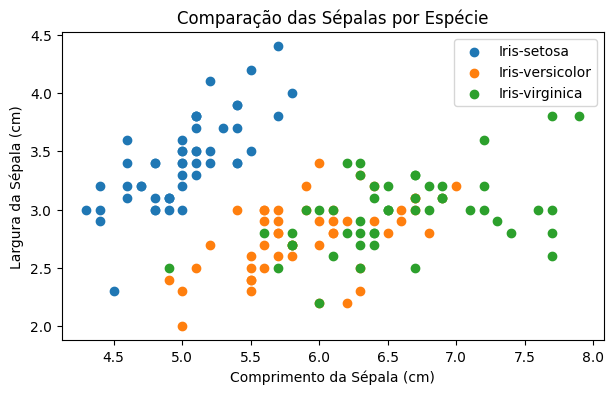

In [3]:
contagem = (
    dados['Species']
    .value_counts()
    .rename_axis('Espécie')
    .reset_index(name='Quantidade')
)

display(contagem)


plt.figure(figsize=(7, 4))

for especie, grupo in dados.groupby('Species'):
    plt.scatter(
        grupo['SepalLengthCm'],
        grupo['SepalWidthCm'],
        label=especie
    )

plt.xlabel('Comprimento da Sépala (cm)')
plt.ylabel('Largura da Sépala (cm)')
plt.title('Comparação das Sépalas por Espécie')
plt.legend()
plt.show()


## 4. Preparação dos dados

A coluna `Id` não será usada, pois serve apenas como identificador. As quatro medidas das flores serão usadas para prever a espécie.


In [4]:
X = dados[
    ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
]

y = dados['Species']

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

divisao = pd.DataFrame({
    'Conjunto': ['Treino', 'Teste'],
    'Amostras': [len(X_treino), len(X_teste)]
})

display(divisao)

,Conjunto,Amostras
0,Treino,120
1,Teste,30


## 5. SVM Linear

In [5]:
modelo_linear = Pipeline([
    ('padronizacao', StandardScaler()),
    ('svm', SVC(kernel='linear', C=1.0))
])

modelo_linear.fit(X_treino, y_treino)
pred_linear = modelo_linear.predict(X_teste)

acc_linear = accuracy_score(y_teste, pred_linear)

resultado_linear = pd.DataFrame({
    'Modelo': ['SVM Linear'],
    'Acurácia': [acc_linear]
})

display(resultado_linear.style.format({'Acurácia':'{:.2%}'}))

relatorio = pd.DataFrame(
    classification_report(
        y_teste,
        pred_linear,
        output_dict=True
    )
).transpose()

display(relatorio.round(3))

,Modelo,Acurácia
0,SVM Linear,100.00%


,precision,recall,f1-score,support
Iris-setosa,1.0,1.0,1.0,10.0
Iris-versicolor,1.0,1.0,1.0,10.0
Iris-virginica,1.0,1.0,1.0,10.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,30.0
weighted avg,1.0,1.0,1.0,30.0


## 6. SVM RBF

,Modelo,Acurácia
0,SVM RBF,96.67%


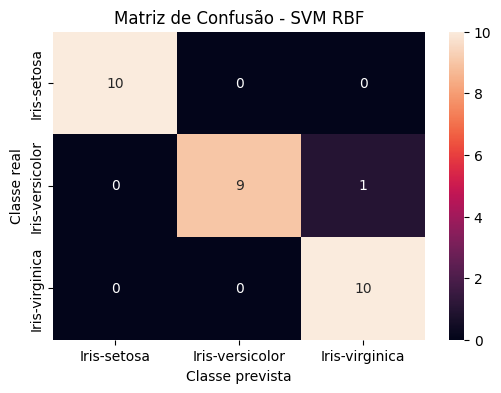

In [6]:
modelo_rbf = Pipeline([
    ('padronizacao', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale'))
])

modelo_rbf.fit(X_treino, y_treino)
pred_rbf = modelo_rbf.predict(X_teste)

acc_rbf = accuracy_score(y_teste, pred_rbf)

resultado_rbf = pd.DataFrame({
    'Modelo': ['SVM RBF'],
    'Acurácia': [acc_rbf]
})

display(resultado_rbf.style.format({'Acurácia':'{:.2%}'}))

matriz = confusion_matrix(y_teste, pred_rbf)

plt.figure(figsize=(6, 4))
sns.heatmap(
    matriz,
    annot=True,
    fmt='d',
    xticklabels=modelo_rbf.classes_,
    yticklabels=modelo_rbf.classes_
)

plt.title('Matriz de Confusão - SVM RBF')
plt.xlabel('Classe prevista')
plt.ylabel('Classe real')
plt.show()

## 7. SVM Polinomial

In [7]:
modelo_poly = Pipeline([
    ('padronizacao', StandardScaler()),
    ('svm', SVC(kernel='poly', degree=3, C=1.0))
])

modelo_poly.fit(X_treino, y_treino)
pred_poly = modelo_poly.predict(X_teste)

acc_poly = accuracy_score(y_teste, pred_poly)

resultado_poly = pd.DataFrame({
    'Modelo': ['SVM Polinomial'],
    'Acurácia': [acc_poly]
})

display(resultado_poly.style.format({'Acurácia':'{:.2%}'}))

,Modelo,Acurácia
0,SVM Polinomial,90.00%


## 8. Validação cruzada

Será usada validação cruzada com 5 folds para comparar os três modelos.

In [8]:
cv_linear = cross_val_score(modelo_linear, X, y, cv=5)
cv_rbf = cross_val_score(modelo_rbf, X, y, cv=5)
cv_poly = cross_val_score(modelo_poly, X, y, cv=5)

tabela_cv = pd.DataFrame({
    'Fold': [1, 2, 3, 4, 5],
    'Linear': cv_linear,
    'RBF': cv_rbf,
    'Polinomial': cv_poly
})

display(tabela_cv.round(3))

resumo_cv = pd.DataFrame({
    'Modelo': ['Linear', 'RBF', 'Polinomial'],
    'Média': [
        np.mean(cv_linear),
        np.mean(cv_rbf),
        np.mean(cv_poly)
    ],
    'Desvio-padrão': [
        np.std(cv_linear),
        np.std(cv_rbf),
        np.std(cv_poly)
    ]
})

display(resumo_cv.round(3))

,Fold,Linear,RBF,Polinomial
0,1,0.967,0.967,0.967
1,2,1.000,0.967,0.967
2,3,0.933,0.967,0.867
3,4,0.933,0.933,0.867
4,5,1.000,1.000,0.967


,Modelo,Média,Desvio-padrão
0,Linear,0.967,0.030
1,RBF,0.967,0.021
2,Polinomial,0.927,0.049


## 9. Teste do parâmetro C no kernel RBF

In [9]:
resultados_c = []

for valor_c in [0.1, 1, 10, 100]:
    modelo_teste = Pipeline([
        ('padronizacao', StandardScaler()),
        ('svm', SVC(kernel='rbf', C=valor_c, gamma='scale'))
    ])

    modelo_teste.fit(X_treino, y_treino)
    previsao = modelo_teste.predict(X_teste)

    resultados_c.append({
        'C': valor_c,
        'Acurácia': accuracy_score(y_teste, previsao)
    })

tabela_c = pd.DataFrame(resultados_c)

display(
    tabela_c.style
    .format({'C':'{:.1f}', 'Acurácia':'{:.2%}'})
    .highlight_max(subset=['Acurácia'])
)


,C,Acurácia
0,0.1,90.00%
1,1.0,96.67%
2,10.0,96.67%
3,100.0,96.67%
